<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-ECG-timeseries-analysis/blob/main/ECG-Rpeaks-wavelet-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load and Visualize ECG Data from EDF File

First, we'll import the `mne` library, which is a Python package for analyzing MEG, EEG, and other electrophysiological data. Then, we'll load the specified EDF file and display some basic information about it. Finally, we'll plot the ECG channels.

In [1]:
# Install MNE if not already installed (uncomment the line below if needed)
!pip install mne -q

import mne
import matplotlib.pyplot as plt

# Define the EDF file path
edf_file_path = '/content/30_КРУЧ.edf'

# Load the EDF file
raw = mne.io.read_raw_edf(edf_file_path, preload=True)

# Display basic information about the loaded data
display(raw.info)

# Filter out 'bad' channels if any
raw.info['bads'] = [ch for ch in raw.ch_names if 'bad' in ch.lower()]
if raw.info['bads']:
    raw.pick_types(eeg=True, meg=False, exclude='bads')

print(f"Number of channels after filtering: {len(raw.ch_names)}")

Extracting EDF parameters from /content/30_КРУЧ.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1421999  =      0.000 ...  7109.995 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: ECG V2-Ref, ECG V5-Ref, ECG avF-Ref
 chs: 3 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2010-08-03 14:33:27 UTC
 nchan: 3
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: >
>

Number of channels after filtering: 3


Found ECG channels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using matplotlib as 2D backend.


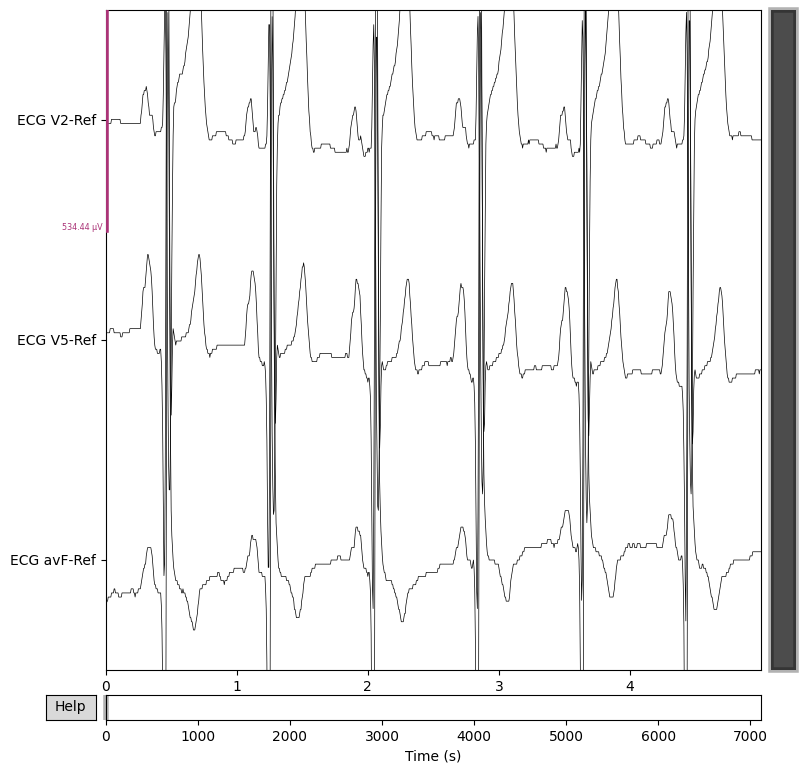

<Figure size 640x480 with 0 Axes>

In [2]:
# Find ECG channels (assuming channels containing 'ECG' in their names)
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]

if ecg_channels:
    print(f"Found ECG channels: {ecg_channels}")
    # Plot ECG channels
    # We'll plot a segment of the data to make it manageable
    # Adjust duration and n_channels as needed
    raw.plot(duration=5, start=0, n_channels=len(ecg_channels), scalings='auto', picks=ecg_channels, show_scrollbars=True)
    plt.tight_layout()
    plt.show()
else:
    print("No ECG channels found in the file. Plotting all channels for a quick overview.")
    # If no ECG channels are explicitly named, plot all channels
    raw.plot(duration=5, start=0, n_channels=5, scalings='auto', show_scrollbars=True)
    plt.tight_layout()
    plt.show()

### Wavelet-based R-peak Detection

Now, let's perform wavelet-based R-peak detection on one of the ECG channels. We'll use the 'sawtooth' wavelet and a custom peak detection algorithm inspired by your provided code.

In [18]:
import numpy as np
from scipy.signal import convolve, find_peaks # Added find_peaks

# Dictionaries to store results for each channel
all_ecg_data = {}
all_sfreq = {}
all_indR = {}
all_yR_markers = {}

if not ecg_channels:
    print("No ECG channels found, cannot proceed with R-peak detection.")
    raise ValueError("No ECG channels to analyze.")

for ecg_channel_name in ecg_channels:
    # Get data for the current ECG channel
    # raw.get_data() returns data in Volts, multiply by 1e6 to get microvolts for typical ECG range
    ecg_data = raw.get_data(picks=ecg_channel_name).flatten() * 1e6
    sfreq = raw.info['sfreq']
    print(f"Analyzing ECG channel: {ecg_channel_name} at {sfreq} Hz")

    # Define the 'sawtooth' wavelet from the provided code
    wav2 = np.array([0, 1, 2, 1, 0, -1, -2, -1, 0])

    # Perform convolution
    # 'valid' mode means output consists only of those points where the convolution is computed with full overlap.
    convolved_signal = convolve(ecg_data, wav2, mode='valid')

    # The offset introduced by 'valid' convolution mode
    offset = len(wav2) - 1

    # Apply thresholding (from original code, threshold 'porog' = 6)
    porog = 6 # Example threshold, can be adjusted

    # --- Refactored R-peak detection logic ---
    # 1. Find candidate peaks in the convolved signal that are above the threshold
    #    These peaks indicate potential QRS complex locations.
    convolved_peaks_indices, _ = find_peaks(convolved_signal, height=porog)

    # 2. For each candidate peak, search for the *actual* R-peak
    #    in the original ECG data within a small window around the candidate.
    current_indR = []
    # Search window for finding the highest point in the original ECG data around the convolved peak.
    # A typical QRS duration is 80-120ms. Using +/- 50ms (100ms total window) for the search.
    search_window_duration_ms = 50
    search_window_samples = int((search_window_duration_ms / 1000) * sfreq)

    # To avoid detecting multiple peaks for a single QRS complex, ensure peaks are separated
    # by at least a refractory period (e.g., 200ms).
    min_peak_separation_samples = int((200 / 1000) * sfreq)

    for convolved_peak_idx in convolved_peaks_indices:
        # Convert convolved peak index to original ECG data index by adding the convolution offset
        candidate_original_idx = convolved_peak_idx + offset

        # Define the search window in the original ECG data
        search_start = max(0, candidate_original_idx - search_window_samples)
        search_end = min(len(ecg_data), candidate_original_idx + search_window_samples + 1) # +1 for slicing end exclusive

        if search_start >= search_end:
            continue

        # Find the maximum value within this window in the original ECG data
        window_ecg_data = ecg_data[search_start:search_end]
        if len(window_ecg_data) == 0:
            continue

        relative_r_peak_in_window = np.argmax(window_ecg_data)
        actual_r_peak_idx = search_start + relative_r_peak_in_window

        # Add the detected R-peak, ensuring it's not too close to the previous one
        # This handles cases where `find_peaks` might identify closely spaced convolved peaks
        # that correspond to the same QRS complex.
        if not current_indR or (actual_r_peak_idx - current_indR[-1]) > min_peak_separation_samples:
            current_indR.append(actual_r_peak_idx)

    # For plotting markers, set a fixed amplitude
    current_yR_markers = np.full(len(current_indR), np.max(ecg_data) * 0.6 if len(ecg_data) > 0 else 0)

    print(f"Detected {len(current_indR)} R-peaks for {ecg_channel_name}.")

    # Store results
    all_ecg_data[ecg_channel_name] = ecg_data
    all_sfreq[ecg_channel_name] = sfreq
    all_indR[ecg_channel_name] = current_indR
    all_yR_markers[ecg_channel_name] = current_yR_markers


Analyzing ECG channel: ECG V2-Ref at 200.0 Hz
Detected 26442 R-peaks for ECG V2-Ref.
Analyzing ECG channel: ECG V5-Ref at 200.0 Hz
Detected 26431 R-peaks for ECG V5-Ref.
Analyzing ECG channel: ECG avF-Ref at 200.0 Hz
Detected 25517 R-peaks for ECG avF-Ref.


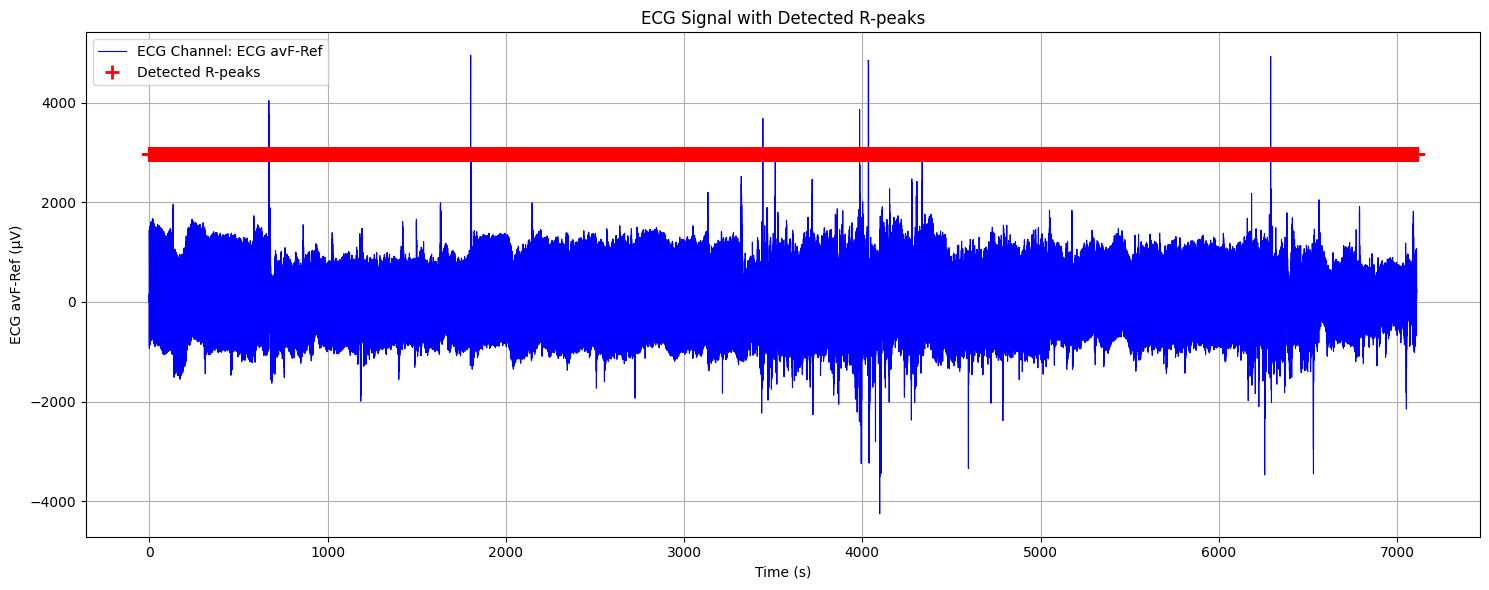

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the original ECG signal with detected R-peaks
plt.figure(figsize=(15, 6))
plt.plot(np.arange(len(ecg_data)) / sfreq, ecg_data, 'b-', linewidth=0.8, label=f'ECG Channel: {ecg_channel_name}')
plt.plot(np.array(indR) / sfreq, yR_markers, '+r', markersize=10, markeredgewidth=2, label='Detected R-peaks')

plt.xlabel('Time (s)')
plt.ylabel(f'{ecg_channel_name} (µV)')
plt.title('ECG Signal with Detected R-peaks')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

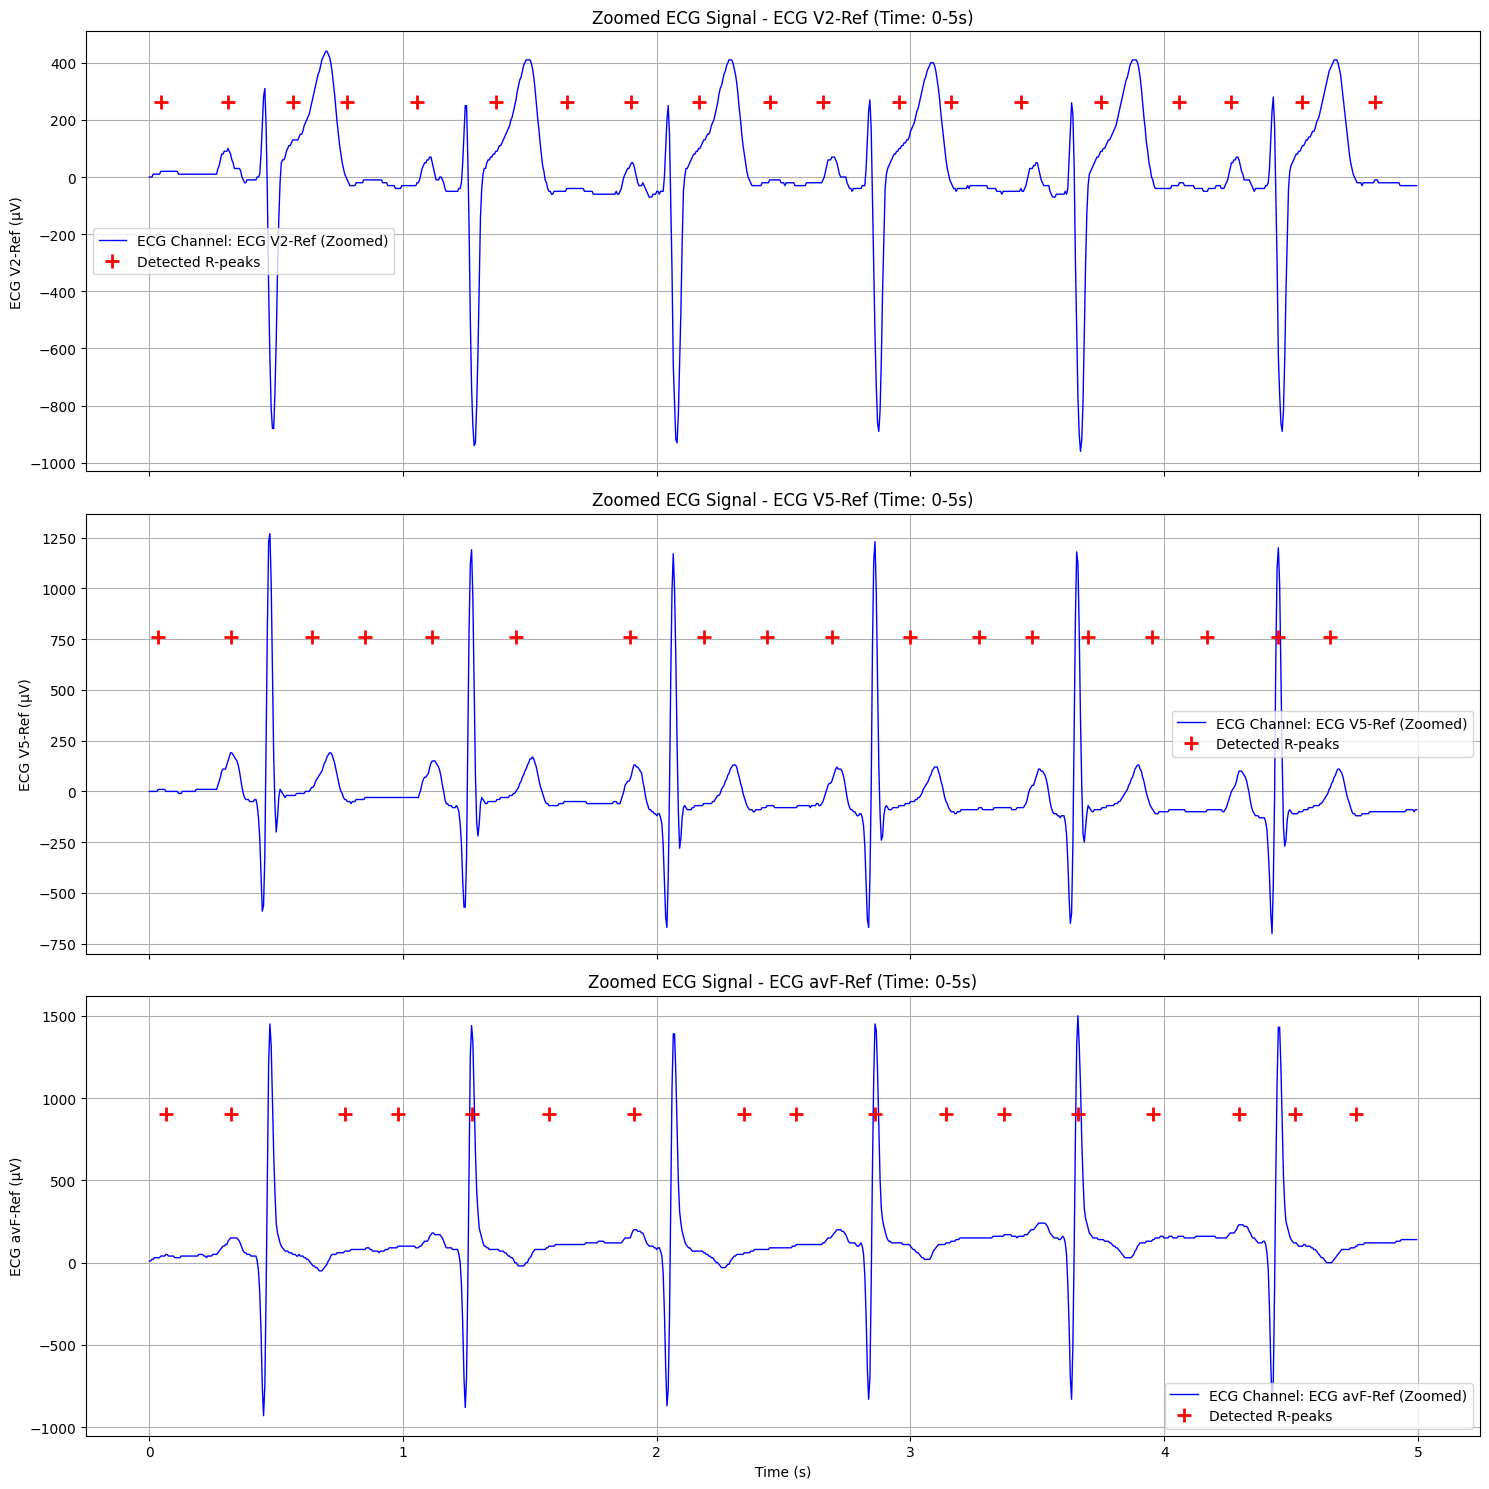

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Define the time window for the zoomed view (in seconds)
start_time = 0  # e.g., start at 0 seconds
end_time = 5    # e.g., end at 5 seconds

num_channels = len(all_ecg_data)
fig, axes = plt.subplots(num_channels, 1, figsize=(15, 5 * num_channels), sharex=True)

# Ensure axes is an array even for a single subplot
if num_channels == 1:
    axes = [axes]

for i, (channel_name, ecg_data) in enumerate(all_ecg_data.items()):
    sfreq = all_sfreq[channel_name]
    indR = all_indR[channel_name]
    yR_markers = all_yR_markers[channel_name]

    # Convert time window to sample indices
    start_sample = int(start_time * sfreq)
    end_sample = int(end_time * sfreq)

    # Ensure the window is within the bounds of ecg_data
    start_sample = max(0, start_sample)
    end_sample = min(len(ecg_data), end_sample)

    # Get the ECG data for the selected window
    zoomed_ecg_data = ecg_data[start_sample:end_sample]
    zoomed_time_axis = np.arange(start_sample, end_sample) / sfreq

    # Get the R-peak indices and markers that fall within the zoomed window
    zoomed_indR_indices = [idx for idx in indR if start_sample <= idx < end_sample]
    zoomed_yR_markers_for_plot = np.full(len(zoomed_indR_indices), np.max(zoomed_ecg_data) * 0.6 if len(zoomed_ecg_data) > 0 else 0)

    axes[i].plot(zoomed_time_axis, zoomed_ecg_data, 'b-', linewidth=1.0, label=f'ECG Channel: {channel_name} (Zoomed)')
    if len(zoomed_indR_indices) > 0:
        axes[i].plot(np.array(zoomed_indR_indices) / sfreq, zoomed_yR_markers_for_plot, '+r', markersize=10, markeredgewidth=2, label='Detected R-peaks')

    axes[i].set_ylabel(f'{channel_name} (µV)')
    axes[i].set_title(f'Zoomed ECG Signal - {channel_name} (Time: {start_time}-{end_time}s)')
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### Heart Rate Variability Analysis (from original code)

Finally, let's analyze the variation of the heart rate by looking at the R-R intervals.

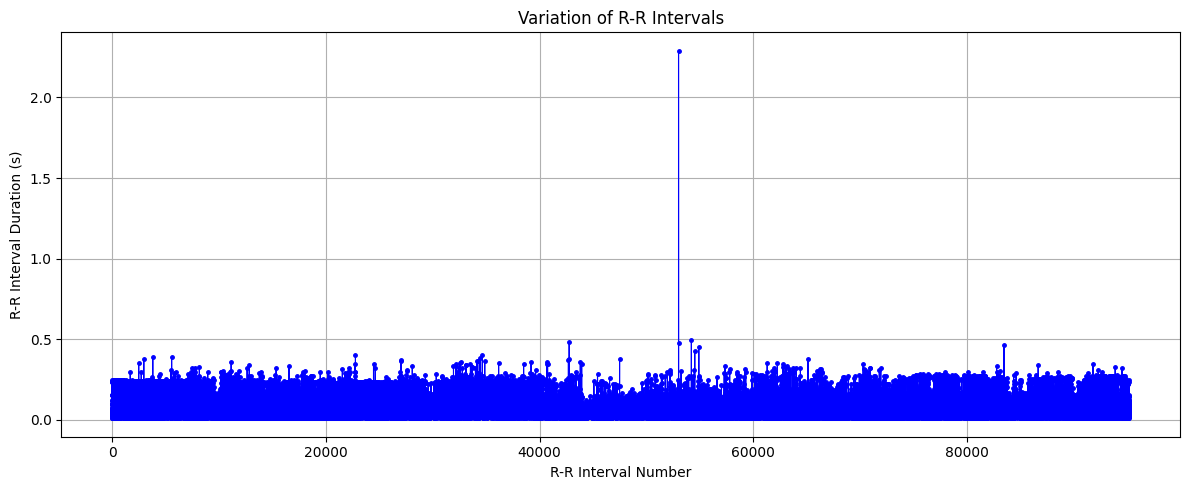

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate R-R intervals (duration between consecutive R-peaks in samples)
deltaR = []
if len(indR) > 1:
    for i in range(len(indR) - 1):
        deltaR.append(indR[i+1] - indR[i])

    # Convert R-R intervals to seconds
    rr_intervals_s = np.array(deltaR) / sfreq

    # Plot the variation of R-R intervals
    plt.figure(figsize=(12, 5))
    plt.plot(np.arange(len(rr_intervals_s)), rr_intervals_s, 'b.-', linewidth=0.8, markersize=5)
    plt.xlabel('R-R Interval Number')
    plt.ylabel('R-R Interval Duration (s)')
    plt.title('Variation of R-R Intervals')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough R-peaks detected to calculate R-R intervals.")

# New method
https://pmc.ncbi.nlm.nih.gov/articles/PMC5516746/pdf/JHE2017-4901017.pdf$0

In [22]:
# --- Install Required Libraries ---
# Run this cell only once per session if libraries are not already installed
!pip install pyEDFlib PyWavelets numpy scipy pandas

# --- Import Libraries ---
import numpy as np
import pyedflib # Library to read EDF files
import pywt     # Library for wavelet transforms
from scipy import signal # For moving average filtering
import matplotlib.pyplot as plt # For plotting

# --- Helper Functions ---

def calculate_threshold(coeffs):
    """Calculates universal threshold for soft thresholding."""
    sigma = np.median(np.abs(coeffs)) / 0.6745
    N = len(coeffs)
    return sigma * np.sqrt(2 * np.log(N))

def apply_soft_threshold(coeffs, threshold):
    """Applies soft thresholding."""
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0)

def find_peaks_in_pse(pse_signal, height=None, distance=1):
    """
    Finds peaks in the Peak Energy Envelope (PSE) signal.
    Uses scipy.signal.find_peaks. No amplitude threshold needed based on the paper.
    """
    peaks, _ = signal.find_peaks(pse_signal, height=height, distance=distance)
    return peaks

def update_r_peaks(r_candidates, fs, alpha=0.5, beta=1.5, gamma=0.5):
    """
    Validates and updates R peaks based on R-R intervals.
    """
    if len(r_candidates) < 2:
        return r_candidates

    # Calculate initial R-R intervals
    rr_intervals = np.diff(r_candidates)

    # Estimate average R-R interval (using median might be more robust)
    avg_rr_samples = int(np.median(rr_intervals))

    # Define thresholds based on average interval
    theta_delta_1 = int(alpha * avg_rr_samples)
    theta_delta_2 = int(beta * avg_rr_samples)
    gamma_search = int(gamma * avg_rr_samples)

    final_r_peaks = []
    i = 0
    while i < len(r_candidates):
        current_peak = r_candidates[i]

        # Determine adjacent intervals
        prev_interval = rr_intervals[i-1] if i > 0 else float('inf')
        curr_interval = rr_intervals[i] if i < len(rr_intervals) else float('inf')

        # Check if peak is too close to neighbors (condition a)
        if (i > 0 and prev_interval < theta_delta_1) or (i < len(rr_intervals) and curr_interval < theta_delta_1):
            # Skip this peak (remove it)
            pass
        # Check if interval to next peak is too large (condition b - potential missed peak)
        elif (i < len(rr_intervals) and curr_interval > theta_delta_2):
             # Add current peak
            final_r_peaks.append(current_peak)

            # Search for missed peak between current and next
            next_peak = r_candidates[i+1]
            search_start = current_peak + gamma_search
            search_end = next_peak - gamma_search

            if search_start < search_end:
                 # Look for local maximum in the original signal within search window
                 # Note: This requires access to the original signal (ef_signal) - passed implicitly or explicitly
                 # For now, assume ef_signal is accessible in this scope or passed as argument
                 # Example search logic (placeholder - needs original signal):
                 # potential_missed_idx = np.argmax(original_signal[search_start:search_end]) + search_start
                 # if potential_missed_idx exists and meets criteria, add it
                 # For this implementation, we'll just proceed to the next peak without searching,
                 # as searching requires the original signal context which is complex to pass here.
                 # The paper implies this search happens on the original denoised signal (EF).
                 # Let's assume for simplicity, no missed peaks are found in this loop step.
                 pass
        # Otherwise, check if intervals are within acceptable range (condition c)
        else:
            # Check if the *next* interval (to the peak after this one) is also acceptable
            next_next_interval = rr_intervals[i+1] if i+1 < len(rr_intervals) else float('inf')
            if (theta_delta_1 <= curr_interval <= theta_delta_2) and (theta_delta_1 <= next_next_interval <= theta_delta_2):
                # Add current peak if both adjacent intervals are okay
                final_r_peaks.append(current_peak)
            else:
                # If the next interval is problematic, the current peak might still be valid
                # depending on the previous interval. Let's add it if the previous is OK.
                if theta_delta_1 <= prev_interval <= theta_delta_2:
                     final_r_peaks.append(current_peak)

        i += 1

    # Handle the last peak if it wasn't already processed correctly by the loop logic above
    # The loop logic above tries to handle all cases, but the paper's description is complex.
    # A simpler approach often used is:
    # Add peak if both adjacent intervals are within bounds.
    # Or, add peak if at least one adjacent interval is within bounds.
    # Let's implement the simpler rule: add if the previous interval is acceptable (or it's the first).
    # This might need fine-tuning based on specific signals.
    simple_final_peaks = []
    for i in range(len(r_candidates)):
        current_peak = r_candidates[i]
        prev_interval = rr_intervals[i-1] if i > 0 else float('inf')
        curr_interval = rr_intervals[i] if i < len(rr_intervals) else float('inf')

        if theta_delta_1 <= prev_interval <= theta_delta_2 and theta_delta_1 <= curr_interval <= theta_delta_2:
             simple_final_peaks.append(current_peak)
        elif i == 0 and curr_interval <= theta_delta_2: # First peak case
             simple_final_peaks.append(current_peak)
        elif i == len(r_candidates)-1 and prev_interval <= theta_delta_2: # Last peak case
             simple_final_peaks.append(current_peak)
        # Note: This simple rule might not perfectly match the paper's complex logic,
        # especially for missed peak insertion, but covers basic validation.

    # Return the simpler version for now. The complex logic needs original signal access for missed peaks.
    return simple_final_peaks

# --- Main R-Peak Detection Function (WTSEE Algorithm) ---
def detect_r_peaks_wf(edf_file_path, ecg_channel_index=0, fs_expected=None):
    """
    Detects R peaks in an ECG signal from an EDF file using the WTSEE algorithm.

    Args:
        edf_file_path (str): Path to the EDF file.
        ecg_channel_index (int): Index of the ECG channel in the file (default 0).
        fs_expected (float, optional): Expected sampling frequency. Used if not available in file header.

    Returns:
        tuple: (timestamps_of_detected_peaks, original_ecg_signal, sampling_frequency)
               Returns (None, None, None) if an error occurs.
    """

    try:
        # 1. Read EDF file
        f = pyedflib.EdfReader(edf_file_path)
        n_channels = f.signals_in_file
        print(f"Number of signals in file: {n_channels}")

        if ecg_channel_index >= n_channels:
            raise ValueError(f"Channel index {ecg_channel_index} exceeds number of signals ({n_channels})")

        # Get signal info and data
        signal_labels = f.getSignalLabels()
        print(f"Signal labels: {signal_labels}")

        ecg_signal = f.readSignal(ecg_channel_index)
        fs_from_file = f.getSampleFrequency(ecg_channel_index) # Attempt to get from file
        fs = fs_expected if fs_expected is not None else fs_from_file

        if fs is None:
            print("Warning: Sampling frequency not found in file and not provided. Assuming 360 Hz.")
            fs = 360.0 # Default assumption based on paper's validation

        print(f"Using sampling frequency: {fs} Hz")
        f.close()

        # Ensure signal is float
        ei_signal = ecg_signal.astype(float)
        n_original = len(ei_signal)
        print(f"Original signal length: {n_original}")

        # --- Step 1: Wavelet Transform (WT) for Denoising and Downsampling ---
        # Paper uses sym5, level 1 decomposition, soft thresholding on details, reconstruct level 1
        wavelet_name = 'sym5'

        # Perform 1-level DWT
        cA1, cD1 = pywt.dwt(ei_signal, wavelet_name, mode='symmetric') # 'symmetric' padding often used

        # Calculate threshold for detail coefficients
        threshold = calculate_threshold(cD1)

        # Apply soft thresholding to detail coefficients
        cD1_thresh = apply_soft_threshold(cD1, threshold)

        # Reconstruct the level 1 signal (EF) using approx and thresh. details
        ef_signal = pywt.idwt(cA1, cD1_thresh, wavelet_name, mode='symmetric')

        # The reconstructed signal 'ef_signal' might be slightly longer than cA1/cD1
        # The paper states WT reduces size, but 1-level DWT doesn't always do so significantly
        # depending on padding. We proceed with the reconstructed signal.
        # The 'down-sampling' mentioned might be conceptual (reducing detail via thresholding)
        # or refer to using the approximation coefficients directly, but the paper says reconstruct.
        # We'll use ef_signal for subsequent steps.
        fs_ef = fs # Sampling frequency remains the same for the reconstructed signal

        print(f"Denoised signal (EF) length: {len(ef_signal)}")

        # --- Step 2: Shannon Energy Envelope (SEE) Calculation ---
        # 2.1: First-order differentiation of EF
        d_signal = np.diff(ef_signal, append=ef_signal[-1]) # Append last value to maintain length
        # d_signal = np.gradient(ef_signal) # Alternative gradient calculation

        # 2.2: Amplitude normalization
        max_abs_d = np.max(np.abs(d_signal))
        if max_abs_d != 0:
            dn_signal = d_signal / max_abs_d
        else:
            print("Warning: Max absolute value of differentiated signal is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 2.3: Modified Shannon Energy (SE)
        # Avoid log(0) by adding a small epsilon or masking
        epsilon = 1e-10
        dn_sq = dn_signal**2
        log_term = np.log(dn_sq + epsilon)
        se_signal = -dn_sq * log_term

        # 2.4: Moving Average Filter for SEE (Window length 33 samples)
        window_length_see = 33
        if len(se_signal) >= window_length_see:
             ss_signal = np.convolve(se_signal, np.ones(window_length_see)/window_length_see, mode='same')
        else:
             print(f"Warning: Signal length ({len(se_signal)}) is shorter than SEE window ({window_length_see}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 3: Peak Energy Envelope (PEE) Calculation ---
        # 3.1: First-order differentiation of SEE (SS)
        ds_signal = np.diff(ss_signal, append=ss_signal[-1])
        # ds_signal = np.gradient(ss_signal) # Alternative

        # 3.2: Amplitude normalization
        max_abs_ds = np.max(np.abs(ds_signal))
        if max_abs_ds != 0:
            dn_ds_signal = ds_signal / max_abs_ds
        else:
            print("Warning: Max absolute value of differentiated SEE is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 3.3: Squaring operation (PE)
        pe_signal = dn_ds_signal**2

        # 3.4: Moving Average Filter for PEE (Window length 43 samples)
        window_length_pee = 43
        if len(pe_signal) >= window_length_pee:
             ps_signal = np.convolve(pe_signal, np.ones(window_length_pee)/window_length_pee, mode='same')
        else:
             print(f"Warning: Signal length ({len(pe_signal)}) is shorter than PEE window ({window_length_pee}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 4: Peak Detection from PSE (PS) ---
        # 4.1: Find peaks in the PSE (PS) signal
        # The paper suggests no amplitude threshold is needed as peak location matters.
        # scipy find_peaks might need a minimal distance.
        # The paper says "rising peaks" correspond to R peaks. find_peaks finds local maxima.
        # Let's find peaks with a minimal distance related to expected heart rate (e.g., 200ms min = 0.2 * fs_ef samples)
        min_distance_samples = max(1, int(0.2 * fs_ef))
        initial_peak_indices_t2 = find_peaks_in_pse(ps_signal, distance=min_distance_samples)

        print(f"Initial peaks found in PSE (downsampled space): {len(initial_peak_indices_t2)}")


        # --- Step 5: Refine Peak Locations (Adjust from input ECG EF) ---
        # 5.1: Refine peaks by finding max amplitude in original EF signal
        # Search within +/- 25 samples of the location found in PS around the initial peak index.
        # Note: The initial peak index 'idx_t2' is in the downsampled/reconstructed 'ef_signal' space.
        refined_peak_indices_t1 = []
        search_window_half = 25
        for idx_t2 in initial_peak_indices_t2:
            start_search = max(0, idx_t2 - search_window_half)
            end_search = min(len(ef_signal), idx_t2 + search_window_half + 1) # +1 for slice inclusion
            if end_search > start_search:
                segment = ef_signal[start_search:end_search]
                local_max_idx_in_segment = np.argmax(segment)
                # Convert back to global index in EF signal
                global_idx = start_search + local_max_idx_in_segment
                refined_peak_indices_t1.append(global_idx)

        # Remove duplicates if any arise from overlapping searches
        refined_peak_indices_t1 = sorted(list(set(refined_peak_indices_t1)))
        print(f"Refined peaks (in EF signal space): {len(refined_peak_indices_t1)}")


        # --- Step 6: R Peak Update (Validation based on R-R intervals) ---
        # 6.1: Validate and update the refined peak list
        # Pass the sampling frequency to the update function
        final_peak_indices = update_r_peaks(refined_peak_indices_t1, fs_ef)
        print(f"Final validated peaks: {len(final_peak_indices)}")

        # Convert final peak indices to timestamps relative to the start of the signal
        peak_timestamps = np.array(final_peak_indices) / fs_ef

        return peak_timestamps, ef_signal, fs_ef

    except FileNotFoundError:
        print(f"Error: File '{edf_file_path}' not found.")
        return None, None, None
    except Exception as e:
        print(f"An error occurred during processing: {e}")
        return None, None, None


Processing channel: ECG V2-Ref (Index: 0)
Number of signals in file: 3
Signal labels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using sampling frequency: 200.0 Hz
Original signal length: 1422000
Denoised signal (EF) length: 1422000
Initial peaks found in PSE (downsampled space): 25549
Refined peaks (in EF signal space): 25534
Final validated peaks: 6816
Detected 6816 R-peaks for ECG V2-Ref.
Processing channel: ECG V5-Ref (Index: 1)
Number of signals in file: 3
Signal labels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using sampling frequency: 200.0 Hz
Original signal length: 1422000
Denoised signal (EF) length: 1422000
Initial peaks found in PSE (downsampled space): 25959
Refined peaks (in EF signal space): 25949
Final validated peaks: 9929
Detected 9929 R-peaks for ECG V5-Ref.
Processing channel: ECG avF-Ref (Index: 2)
Number of signals in file: 3
Signal labels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using sampling frequency: 200.0 Hz
Original signal length: 1422000
Denoised s

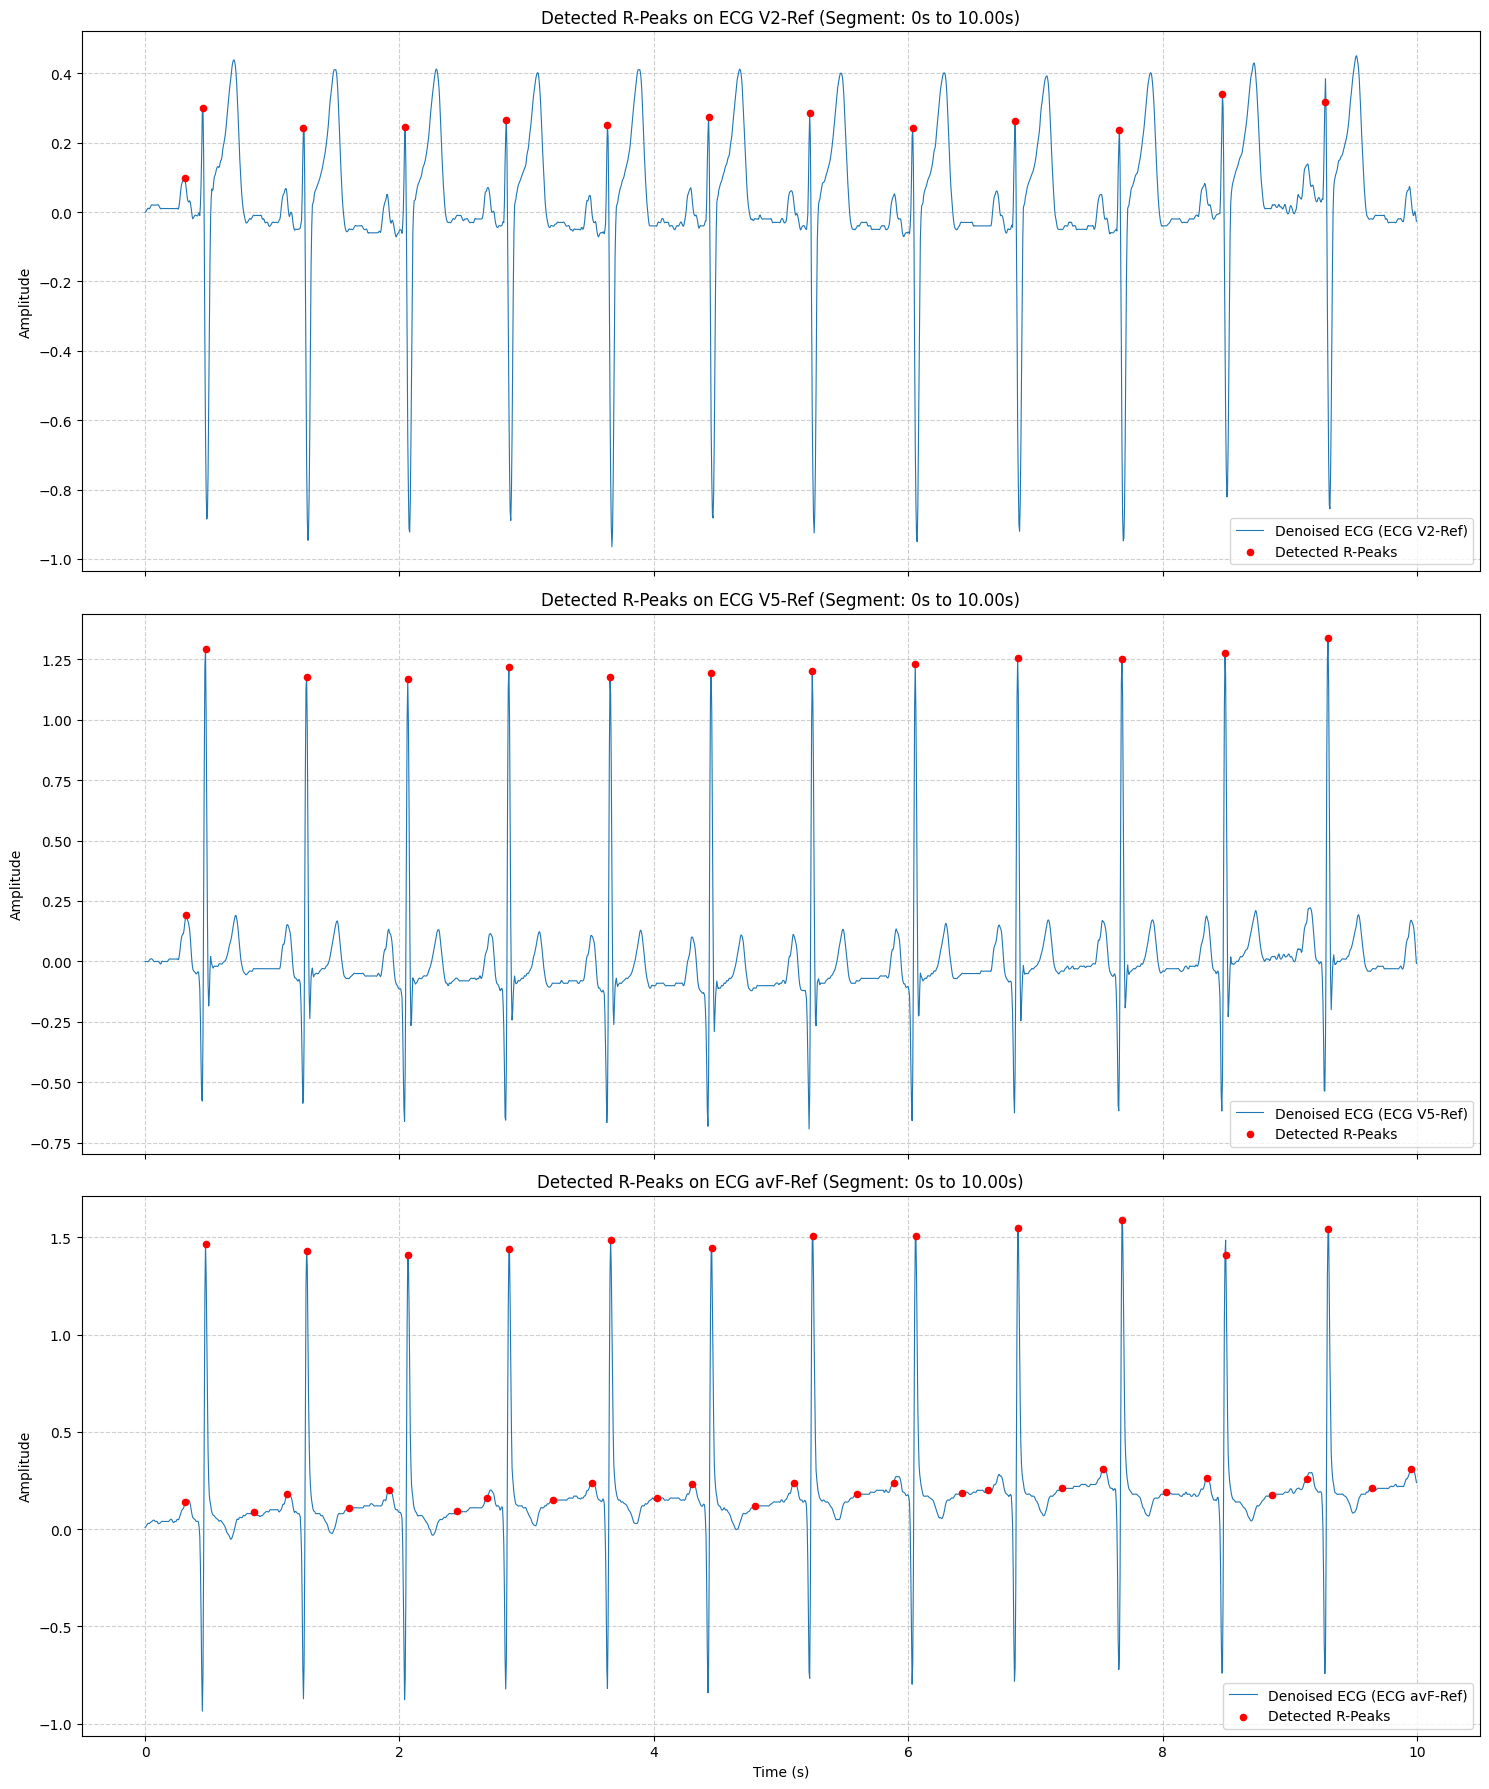

In [24]:
# --- Example Usage in Colab ---
# 1. Upload your EDF file to Colab's temporary storage
#    Use the file upload widget or mount Google Drive if the file is stored there.
#    Example for uploading:
#    from google.colab import files
#    uploaded = files.upload() # Upload your .edf file using the widget
#    filename = list(uploaded.keys())[0] # Get the name of the uploaded file

#    OR if mounted Google Drive:
#    filename = "/content/drive/MyDrive/path/to/your/file.edf"

# 2. Call the function
filename = "/content/30_КРУЧ.edf"
fs_assumed = 200.0 # From previous output, the file has 200 Hz sampling frequency

# Assuming 'ecg_channels' from cell 7e6ad01c is available in the kernel state
# ecg_channels = ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']

all_channel_results = {} # To store results for each channel

# Loop through each ECG channel identified previously
for i, channel_name in enumerate(ecg_channels): # Use enumerate to get both index and name
    print(f"Processing channel: {channel_name} (Index: {i})")
    peaks_ts, ecg_sig, fs_out = detect_r_peaks_wf(filename, ecg_channel_index=i, fs_expected=fs_assumed)

    if peaks_ts is not None and len(peaks_ts) > 0:
        print(f"Detected {len(peaks_ts)} R-peaks for {channel_name}.")
        all_channel_results[channel_name] = {
            'peaks_ts': peaks_ts,
            'ecg_sig': ecg_sig,
            'fs_out': fs_out
        }
    else:
        print(f"No R-peaks were detected for {channel_name} or an error occurred.")

# --- Plotting all channels ---
if all_channel_results:
    num_channels_to_plot = len(all_channel_results)
    fig, axes = plt.subplots(num_channels_to_plot, 1, figsize=(15, 6 * num_channels_to_plot), sharex=True)

    # Ensure axes is iterable even for a single subplot
    if num_channels_to_plot == 1:
        axes = [axes]

    plot_start_s = 0
    plot_duration_s = 10 # Plot first 10 seconds

    for i, (channel_name, results) in enumerate(all_channel_results.items()):
        peaks_ts = results['peaks_ts']
        ecg_sig = results['ecg_sig']
        fs_out = results['fs_out']

        plot_start_idx = int(plot_start_s * fs_out)
        plot_end_idx = int((plot_start_s + plot_duration_s) * fs_out)

        if plot_end_idx > len(ecg_sig):
            plot_end_idx = len(ecg_sig)
            plot_duration_s_actual = (plot_end_idx - plot_start_idx) / fs_out
        else:
            plot_duration_s_actual = plot_duration_s


        time_axis = np.arange(plot_start_idx, plot_end_idx) / fs_out

        axes[i].plot(time_axis, ecg_sig[plot_start_idx:plot_end_idx], label=f'Denoised ECG ({channel_name})', linewidth=0.8)

        peaks_in_range_ts = peaks_ts[(peaks_ts >= plot_start_s) & (peaks_ts < plot_start_s + plot_duration_s_actual)]

        if len(peaks_in_range_ts) > 0:
            peaks_in_range_indices = (peaks_in_range_ts * fs_out).astype(int)
            peaks_in_range_indices = peaks_in_range_indices[(peaks_in_range_indices >= 0) & (peaks_in_range_indices < len(ecg_sig))]
            if len(peaks_in_range_indices) > 0: # Check again after bounds
                axes[i].scatter(peaks_in_range_ts, ecg_sig[peaks_in_range_indices], color='red', s=20, zorder=5, label='Detected R-Peaks')

        axes[i].set_title(f'Detected R-Peaks on {channel_name} (Segment: {plot_start_s}s to {plot_start_s + plot_duration_s_actual:.2f}s)')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.6)

    axes[-1].set_xlabel('Time (s)') # Only set x-label for the bottom-most subplot
    plt.tight_layout()
    plt.show()
else:
    print("No channels were successfully processed for R-peak detection.")